In [69]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

df = pd.read_csv("spotifydataset.csv")
df.shape
df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [70]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 non-null   i

In [71]:
df.isnull().sum()

Unnamed: 0             0
artist_name            0
genres               163
followers              0
artist_popularity      0
artist_url             0
track_name             0
album_name             0
release_date           0
duration_ms            0
explicit               0
track_popularity       0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
dtype: int64

## Seleccion variables

In [72]:
features = [ # Variables de audio utilizadas para segmentar canciones

    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df[features] # Crear subconjunto únicamente con las variables relevantes

In [73]:
X.isnull().sum() # Contar valores nulos por columna

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

In [74]:
scaler = StandardScaler() # Crear objeto de escalamiento


In [75]:
X_scaled = scaler.fit_transform(X) # Ajustar el escalador y transformar los datos

## PCA

In [76]:
pca = PCA()

pca_result = pca.fit_transform(X_scaled) # Transformar los datos escalados
pca_result

array([[-0.11601143, -0.17958553, -1.09837219, ...,  0.63389368,
        -0.47831614,  0.30722791],
       [ 0.30676432,  0.93946987, -1.25643611, ...,  0.65502521,
         0.05296956,  0.0195638 ],
       [-1.96639019,  0.59406128, -0.70399181, ..., -0.17265917,
         0.15018454, -0.24955694],
       ...,
       [ 1.70629551,  0.13695471, -0.26504016, ..., -0.19313022,
         0.08917411,  0.78377106],
       [ 1.73784374, -0.64035438,  2.48892936, ...,  1.27108498,
         0.28175051,  0.36426614],
       [ 1.56908997,  0.96245724,  1.52766174, ...,  0.77250776,
        -0.14906849,  0.13031045]], shape=(1000, 9))

## Reducir a tres componentes

In [77]:
pca = PCA(n_components=3) # Crear PCA utilizando únicamente 3 componentes

pca_result = pca.fit_transform(X_scaled) # Aplicar reducción de dimensionalidad
pca_result

array([[-0.11601143, -0.17958553, -1.09837219],
       [ 0.30676432,  0.93946987, -1.25643611],
       [-1.96639019,  0.59406128, -0.70399181],
       ...,
       [ 1.70629551,  0.13695471, -0.26504016],
       [ 1.73784374, -0.64035438,  2.48892936],
       [ 1.56908997,  0.96245724,  1.52766174]], shape=(1000, 3))

## DataFrame con los componentes principales

In [78]:
pca_df = pd.DataFrame( # Convertir resultado PCA a DataFrame
    pca_result,
    columns=["PC1", "PC2", "PC3"]
)

# Mostrar primeras filas
print(pca_df.head())

        PC1       PC2       PC3
0 -0.116011 -0.179586 -1.098372
1  0.306764  0.939470 -1.256436
2 -1.966390  0.594061 -0.703992
3  1.129420  0.014931 -1.090039
4  0.991172  1.135245 -0.494455


In [79]:
inertia = [] # Lista para almacenar la inercia de cada modelo


for k in range(2,11): # Probar diferentes cantidades de clusters


    modelo = KMeans(     # Crear modelo K-Means

        n_clusters=k,
        random_state=42
    )

    modelo.fit(pca_df)     # Entrenar modelo


    inertia.append(modelo.inertia_)     # Guardar inercia


## Graficar

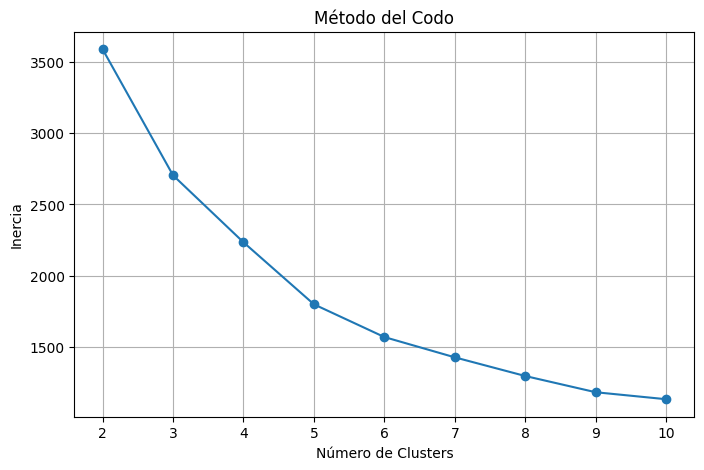

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.grid(True)

plt.show()

In [81]:
kmeans = KMeans( # Crear modelo K-Means final

    n_clusters=3,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(pca_df) # Asignar cluster a cada canción

## Visualización PCA 2D

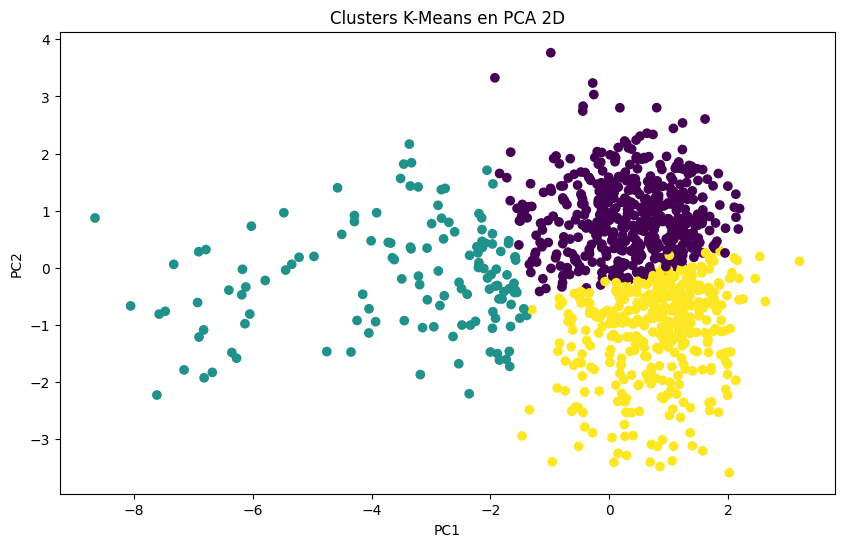

In [82]:
plt.figure(figsize=(10,6))

plt.scatter( # Graficar componentes principales

    pca_df["PC1"],
    pca_df["PC2"],
    c=df["cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Clusters K-Means en PCA 2D"
)

plt.show()

Lo hice con 4 clusters pero no se diferenciaban los morados y amarrillos asi que lo deje en 3 

## Grafico 3D

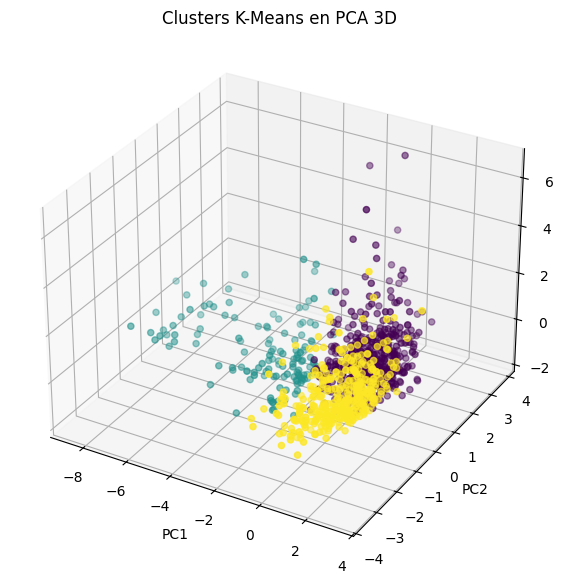

In [83]:
fig = plt.figure(figsize=(10,7)) # Crear figura


ax = fig.add_subplot( # Crear eje tridimensional

    111,
    projection="3d"
)

ax.scatter( # Graficar canciones

    pca_df["PC1"],
    pca_df["PC2"],
    pca_df["PC3"],
    c=df["cluster"]
)

ax.set_xlabel("PC1") #Etiquetas
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title(
    "Clusters K-Means en PCA 3D"
)

plt.show()

## Promedio de cada cluster

In [84]:
cluster_profile = ( # Calcular promedio de cada variable por cluster

  df.groupby("cluster")[features]
  .mean()
  .reset_index()
)
cluster_profile

,cluster,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,0.716292,0.646850,-6.691858,0.106844,0.272058,0.008141,0.146834,0.628753,113.005202
1,1,0.450726,0.316802,-14.517681,0.049755,0.736225,0.375475,0.130169,0.312333,117.417919
2,2,0.534206,0.800594,-5.140483,0.086434,0.090314,0.052914,0.263526,0.445652,135.544858


## Gráfico de barras comparativo

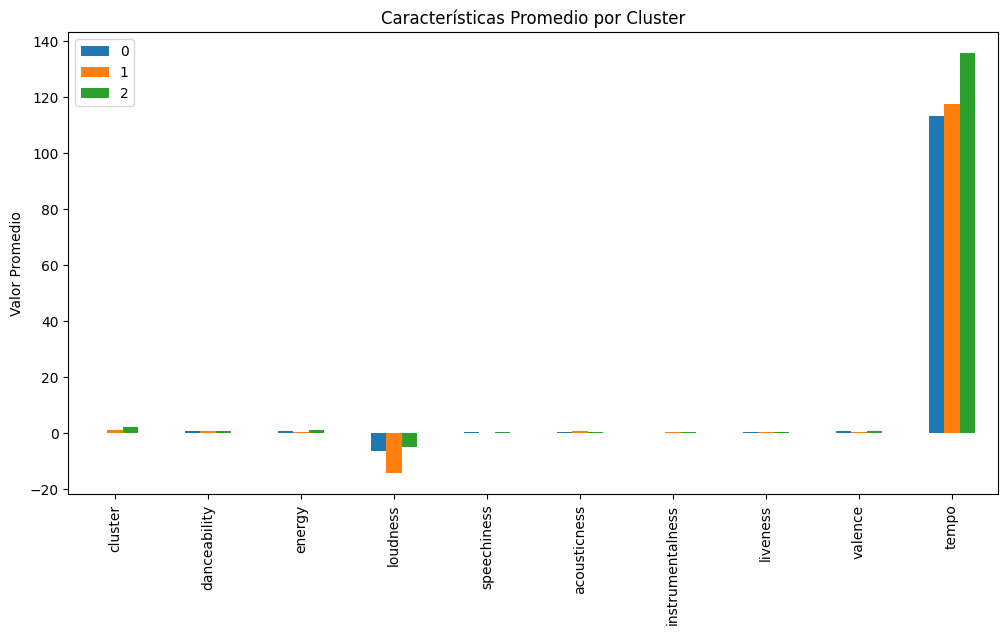

In [85]:
cluster_profile.T.plot( # Comparar promedios de cada cluster

    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Características Promedio por Cluster"
)

plt.ylabel("Valor Promedio")

plt.show()

# Conclusiones

En este proyecto se aplicó un flujo completo de aprendizaje no supervisado para segmentar canciones de Spotify a partir de sus características de audio. Inicialmente se realizó un proceso de preprocesamiento y normalización de los datos para garantizar que todas las variables tuvieran la misma importancia durante el análisis. Posteriormente, se utilizó PCA (Análisis de Componentes Principales) para reducir la dimensionalidad del conjunto de datos, conservando la mayor parte de la información relevante y facilitando la visualización de patrones ocultos.

A partir de los componentes principales obtenidos, se implementó el algoritmo K-Means para identificar grupos de canciones con características similares. La selección del número de clusters se realizó mediante el Método del Codo, permitiendo encontrar una segmentación adecuada de los datos. Las visualizaciones en 2D y 3D mostraron una separación clara entre los grupos encontrados, mientras que los gráficos comparativos permitieron analizar las diferencias en variables como energía, danceability, acousticness, instrumentalness y valence.

El análisis evidenció que es posible agrupar canciones según sus características sonoras y construir perfiles musicales diferenciados. Algunos clusters estuvieron asociados a música más energética y bailable, mientras que otros representaron canciones más acústicas, instrumentales o relajadas. Esta segmentación permite comprender mejor el comportamiento del catálogo musical y encontrar similitudes entre canciones más allá del género o del artista.

Desde una perspectiva comercial, los resultados obtenidos pueden utilizarse para mejorar sistemas de recomendación, crear playlists automáticas basadas en perfiles de audio y desarrollar estrategias de curación de contenido más precisas. En conclusión, las técnicas de reducción de dimensionalidad y clustering demostraron ser herramientas efectivas para descubrir patrones y generar valor a partir de grandes volúmenes de datos musicales.